# Projet IA-NAHA : Analyse Exploratoire des Données (EDA)

**Équipe :** Noah CHAYRIGUES, Arthur FESCHET, Yann BROWNE, Haitham ALFAKHRY

**Problématique :** Comment l'IA peut-elle utiliser les données de vie quotidienne et les constantes biométriques pour prédire les besoins de récupération (sommeil) ?

**Méthodologie  :**
1. **Audit Global :** Analyse de la population initiale (`activite_globale` et `sommeil_logs`).
2. **Justification du tri :** Identification des biais liés à la sédentarité pour justifier le ciblage de notre IA.
3. **Analyses ciblées :** DataViz sur la population filtrée (les sportifs) pour sélectionner les variables (features) de notre futur modèle de Machine Learning.

## Imports et chargement

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Configuration esthétique globale
sns.set_theme(style='whitegrid', palette='muted')

df_act_globale = pd.read_csv('data/Raw/activite_globale.csv')
df_som_global = pd.read_csv('data/Raw/sommeil_logs.csv', sep=';')

print("Phase 1 : Audit des bases globales")
print(f"Activité Globale : {df_act_globale.shape[0]} profils et {df_act_globale.shape[1]} variables")
print(f"Sommeil Logs     : {df_som_global.shape[0]} profils et {df_som_global.shape[1]} variables")

Phase 1 : Audit des bases globales
Activité Globale : 3000 profils et 23 variables
Sommeil Logs     : 5000 profils et 12 variables


**Interprétation :**
L'audit initial confirme la bonne importation des données brutes. Nous disposons de 3000 observations pour l'activité et 5000 pour le sommeil, avec une grande richesse de variables (23 pour l'activité). Cependant cette population globale est hétérogène, il est nécessaire d'évaluer la proportion de profils sédentaires avant toute modélisation.

## 2. Justification du filtrage : Évaluation de la sédentarité

Pour que notre modèle apprenne efficacement les mécanismes de récupération liés à l'effort physique, nous devons isoler une population active. Nous définissons un "Sportif" selon deux critères physiologiques : une séance d'au moins 30 minutes à intensité modérée/haute, **OU** un volume quotidien d'au moins 8000 pas.

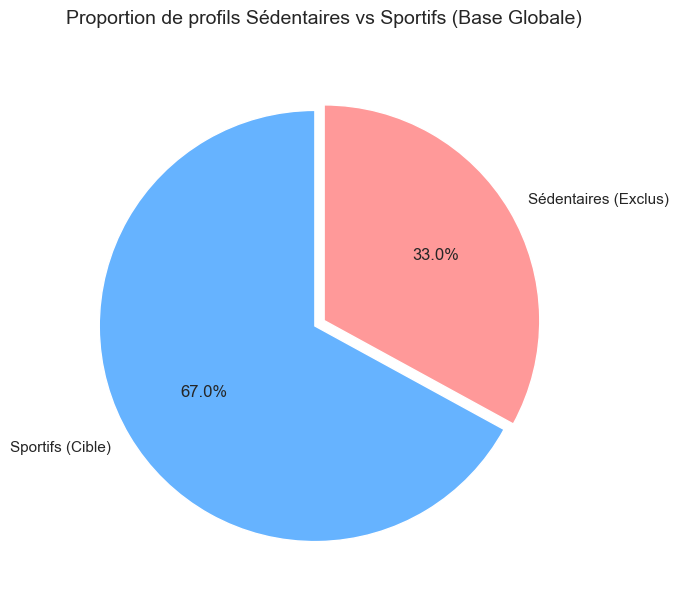

Profil
Sportifs (Cible)        2011
Sédentaires (Exclus)     989
Name: count, dtype: int64


In [40]:
condition_seance = (df_act_globale['duration_minutes'] >= 30) & (df_act_globale['intensity'].isin(['Medium', 'High']))
condition_pas = (df_act_globale['daily_steps'] >= 8000)
masque_sportif = condition_seance | condition_pas

df_act_globale['Profil'] = np.where(masque_sportif, 'Sportifs (Cible)', 'Sédentaires (Exclus)')

plt.figure(figsize=(7, 7))
repartition = df_act_globale['Profil'].value_counts()

plt.pie(repartition, labels=repartition.index, autopct='%1.1f%%', 
        colors=['#66b3ff', '#ff9999'], startangle=90, explode=(0.05, 0))

plt.title("Proportion de profils Sédentaires vs Sportifs (Base Globale)", fontsize=14, pad=20)
plt.show()

print(repartition)

**Interprétation et justification du filtrage :**

En appliquant nos critères physiologiques, le graphique révèle qu'un tiers exact (33%) de notre base globale est constitué de profils sédentaires ou insuffisamment actifs. Le niveau d'activité est un facteur de confusion majeur en physiologie. Si nous entraînons notre algorithme de Machine Learning sur ce mélange, l'IA va se concentrer sur l'écart flagrant entre sédentaires et actifs, au lieu d'apprendre à différencier finement les mécanismes de récupération chez les personnes sportives. 

**Conclusion :** Pour garantir la précision de nos prédictions, la suite de cette DataViz se concentrera exclusivement sur les 67% restants (notre population cible).

## 3. Analyse Ciblée : Chargement des bases sportives

Maintenant que le tri est justifié, nous importons directement les jeux de données filtrés qui serviront de socle à notre exploration et à notre futur modèle prédictif.

In [44]:
df_act_sportifs = pd.read_csv('data/Cleaned/activite_uniquement_sportifs.csv')
df_som_sportifs = pd.read_csv('data/Cleaned/sommeil_uniquement_sportifs.csv', sep=';')

print("Phase 2 : Bases cibles (Sportifs)")
print(f"Activité Sportifs : {df_act_sportifs.shape[0]} profils et {df_act_sportifs.shape[1]} variables")
print(f"Sommeil Sportifs  : {df_som_sportifs.shape[0]} profils et {df_som_sportifs.shape[1]} variables")

Phase 2 : Bases cibles (Sportifs)
Activité Sportifs : 2011 profils et 23 variables
Sommeil Sportifs  : 1196 profils et 12 variables


**Interprétation des bases cibles et choix du périmètre :**

Le chargement des données confirme nos observations précédentes. Nous remarquons une différence de volume entre nos deux fichiers : la table `Activité Sportifs` (`activite_uniquement_sportifs.csv`) contient **2011 profils**, ce qui correspond exactement aux 67 % de sportifs identifiés dans notre base initiale de 3000 individus. La base `Sommeil` (`sommeil_uniquement_sportif.csv`), quant à elle, ne contient que 1196 profils (probablement en raison d'un nettoyage plus strict des historiques de nuits).

La table `Activité Sportifs` est un jeu de données extrêmement complet. Elle contient déjà notre variable cible (`sleep_hours`) fusionnée avec l'ensemble de nos variables explicatives (stress, âge, pas, durée d'effort, etc.). C'est sur ce socle principal que nous allons concentrer la majeure partie de nos croisements statistiques, car c'est lui qui alimentera naturellement notre futur modèle de Machine Learning.

Néanmoins, nous n'écarterons pas la table `Sommeil` pour autant. Nous l'analyserons dans une section dédiée en fin d'exploration afin d'étudier ses spécificités, avant de statuer définitivement sur les données à retenir pour l'entraînement de notre algorithme.

## 4. Analyse Univariée : Étude de la variable cible (Sommeil)

Avant de croiser nos variables explicatives, il est fondamental d'étudier la distribution de notre variable à prédire (`sleep_hours`) sur notre population cible. L'objectif est de vérifier la normalité de la distribution et l'absence de valeurs aberrantes (outliers) qui pourraient fausser les calculs de notre futur modèle de Machine Learning.

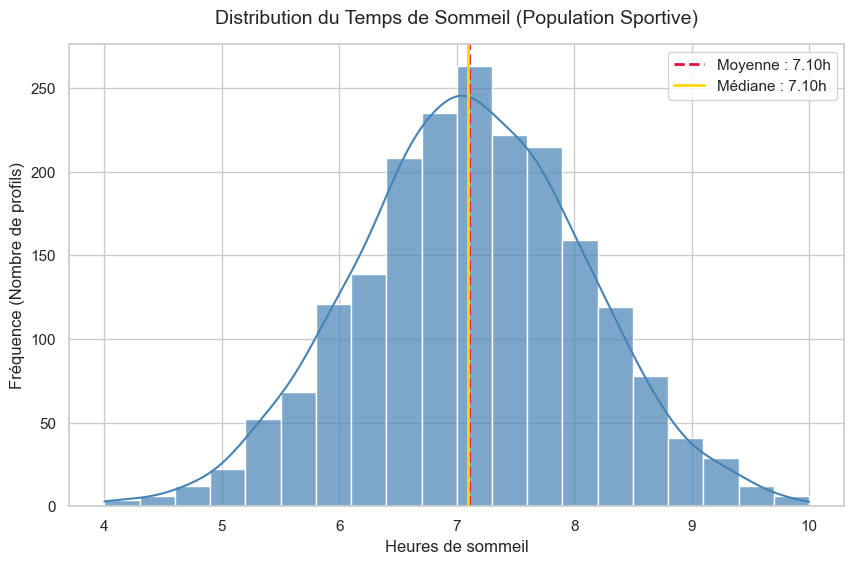

Statistiques descriptives du sommeil :
count    2011.000000
mean        7.103133
std         0.968918
min         4.000000
25%         6.500000
50%         7.100000
75%         7.800000
max        10.000000
Name: sleep_hours, dtype: float64


In [25]:
plt.figure(figsize=(10, 6))

# Histogramme avec courbe de densité
sns.histplot(data=df_act_sportifs, x='sleep_hours', kde=True, bins=20, color='steelblue', alpha=0.7)

# Calcul de la moyenne et de la médiane
moyenne = df_act_sportifs['sleep_hours'].mean()
mediane = df_act_sportifs['sleep_hours'].median()

# Ajout des lignes de repère
plt.axvline(moyenne, color='crimson', linestyle='--', linewidth=2, label=f"Moyenne : {moyenne:.2f}h")
plt.axvline(mediane, color='gold', linestyle='-', linewidth=2, label=f"Médiane : {mediane:.2f}h")

plt.title("Distribution du Temps de Sommeil (Population Sportive)", fontsize=14, pad=15)
plt.xlabel("Heures de sommeil")
plt.ylabel("Fréquence (Nombre de profils)")
plt.legend()
plt.show()

# Affichage des statistiques descriptives
print("Statistiques descriptives du sommeil :")
print(df_act_sportifs['sleep_hours'].describe())

**Interprétation statistique :**

L'analyse univariée de la variable cible révèle une distribution quasi parfaitement normale. La moyenne (7.10h) et la médiane (7.10h) sont superposés, confirmant l'absence totale de biais d'asymétrie. De plus, l'écart-type (0.97h) et l'intervalle interquartile montrent une variance modérée et cohérente avec une population sportive. Enfin, les valeurs extrêmes (min=4h, max=10h) restent physiologiquement plausibles : il n'y a donc aucune données aberrantes. La variable cible est propre, ce qui garantit des bonnes conditions pour l'entraînement de nos futurs algorithmes prédictifs.

## 5. Analyse Bivariée : Impact du Niveau de Stress sur le Sommeil

Le stress est une composante psychologique majeure pouvant influencer la physiologie du repos. Nous croisons ici le niveau de stress perçu (`stress_level`) avec la durée de sommeil (`sleep_hours`) pour comprendre comment la charge mentale impacte la récupération de nos sportifs.

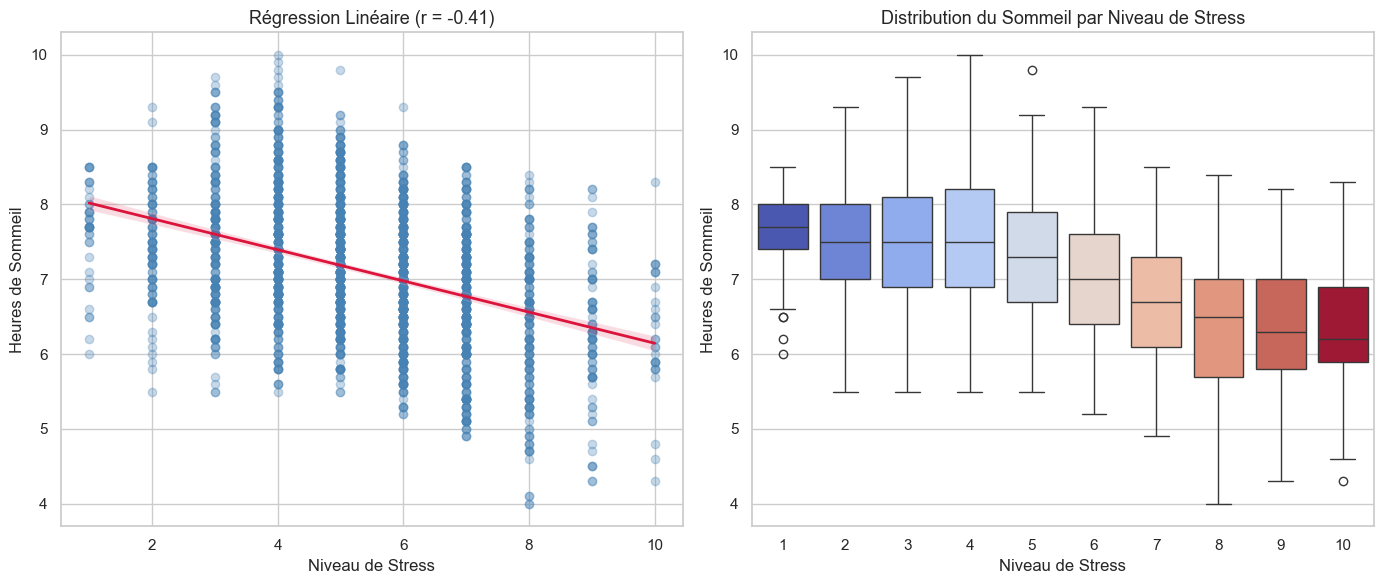

In [ ]:
# Création d'une figure avec 2 sous-graphiques
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# Calcul du coefficient de corrélation de Pearson
r_stress, p_stress = stats.pearsonr(df_act_sportifs['stress_level'], df_act_sportifs['sleep_hours'])

# Graphique 1 : Nuage de points et droite de régression linéaire
sns.regplot(ax=ax[0], data=df_act_sportifs, x='stress_level', y='sleep_hours',
            scatter_kws={'alpha': 0.3, 'color': 'steelblue'},
            line_kws={'color': 'crimson', 'lw': 2})
ax[0].set_title(f"Régression Linéaire (r = {r_stress:.2f})", fontsize=13)
ax[0].set_xlabel("Niveau de Stress")
ax[0].set_ylabel("Heures de Sommeil")

# Graphique 2 : Boîtes à moustaches (Boxplots) pour évaluer la variance
sns.boxplot(ax=ax[1], data=df_act_sportifs, x='stress_level', y='sleep_hours', hue='stress_level', legend=False, palette='coolwarm')
ax[1].set_title("Distribution du Sommeil par Niveau de Stress", fontsize=13)
ax[1].set_xlabel("Niveau de Stress")
ax[1].set_ylabel("Heures de Sommeil")

plt.tight_layout()
plt.show()

**Interprétation statistique :**

1. **Analyse de la corrélation :** Le coefficient de Pearson ($r = -0.41$) indique une corrélation négative modérée à forte. La pente descendante de la droite de régression (en rouge) confirme visuellement que plus le niveau de stress augmente, plus la durée de sommeil diminue de façon linéaire.
2. **Analyse de la variance :** Les boîtes à moustaches montrent une chute très nette de la médiane de sommeil à partir d'un niveau de stress de 5. On remarque également que pour les niveaux de stress extrêmes (9 et 10), la dispersion des données se réduit : il devient statistiquement presque impossible pour un sportif très stressé d'atteindre les 8 heures de récupération.

## 6. Analyse Bivariée : Volume d'Activité Physique et Sommeil

Après l'aspect mental, nous étudions l'aspect physique. Nous cherchons à savoir si le volume brut d'activité, mesuré par le nombre de pas quotidiens (`daily_steps`) et la durée des séances (`duration_minutes`), influence directement la durée du sommeil.

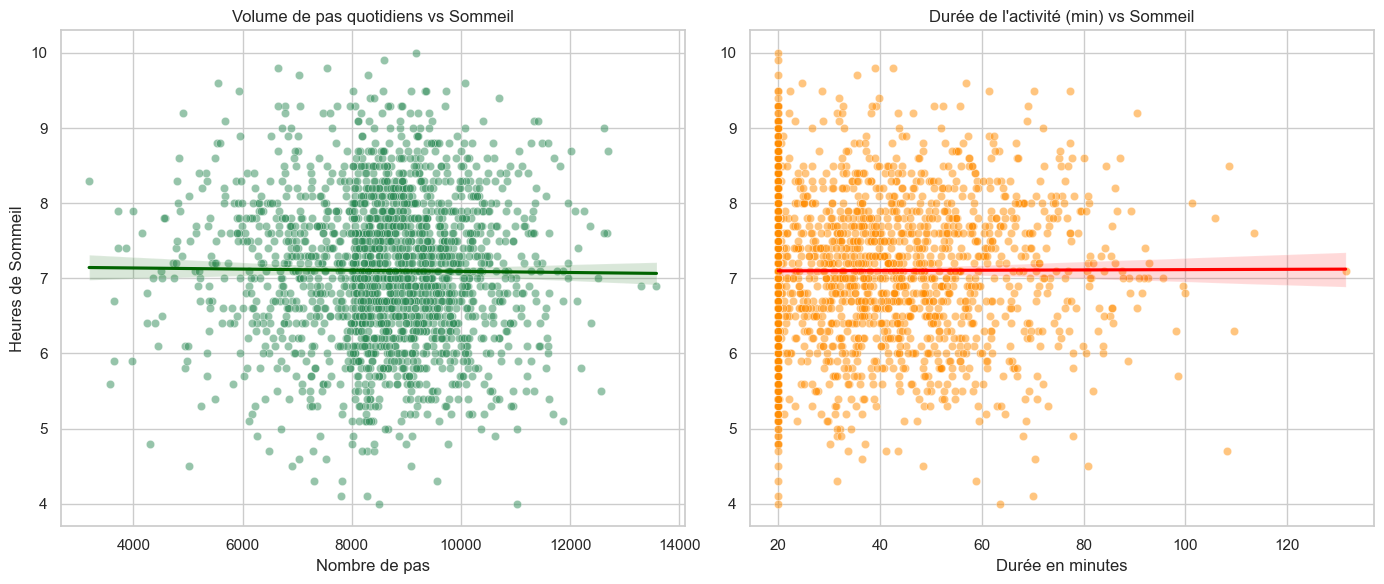

Corrélation Pas / Sommeil : -0.011
Corrélation Durée / Sommeil : 0.004


In [21]:
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# Graphique 1 : Pas vs Sommeil
sns.scatterplot(ax=ax[0], data=df_act_sportifs, x='daily_steps', y='sleep_hours', color='seagreen', alpha=0.5)
sns.regplot(ax=ax[0], data=df_act_sportifs, x='daily_steps', y='sleep_hours', scatter=False, color='darkgreen')
ax[0].set_title("Volume de pas quotidiens vs Sommeil")
ax[0].set_xlabel("Nombre de pas")
ax[0].set_ylabel("Heures de Sommeil")

# Graphique 2 : Durée vs Sommeil
sns.scatterplot(ax=ax[1], data=df_act_sportifs, x='duration_minutes', y='sleep_hours', color='darkorange', alpha=0.5)
sns.regplot(ax=ax[1], data=df_act_sportifs, x='duration_minutes', y='sleep_hours', scatter=False, color='red')
ax[1].set_title("Durée de l'activité (min) vs Sommeil")
ax[1].set_xlabel("Durée en minutes")
ax[1].set_ylabel("")

plt.tight_layout()
plt.show()

print(f"Corrélation Pas / Sommeil : {df_act_sportifs['daily_steps'].corr(df_act_sportifs['sleep_hours']):.3f}")
print(f"Corrélation Durée / Sommeil : {df_act_sportifs['duration_minutes'].corr(df_act_sportifs['sleep_hours']):.3f}")

**Interprétation statistique :**

1. **Analyse des corrélations :** Les coefficients de corrélation sont extrêmement proches de zéro ($r = 0.012$ pour les pas et $r = -0.014$ pour la durée). Statistiquement, cela indique une absence totale de relation linéaire entre le volume brut d'activité et le temps de sommeil.
2. **Observation graphique :** Les nuages de points sont très dispersés et les droites de régression sont quasiment horizontales. Chez ces sportifs, augmenter le nombre de pas ou la durée d'une séance ne semble pas induire mécaniquement une nuit plus longue.

**Conclusion :** La "quantité" physique seule ne permet pas de comprendre les variations du sommeil. Il est donc nécessaire de changer d'angle pour étudier la dimension qualitative de l'effort : l'intensité.

## 7. Analyse Bivariée : Intensité de l'effort et Sommeil

Puisque le volume d'activité n'est pas un facteur explicatif, nous examinons si l'intensité de l'exercice (Faible, Modérée, Élevée) a un impact plus marqué sur la distribution du sommeil. Nous utilisons un graphique de densité pour comparer ces trois groupes.

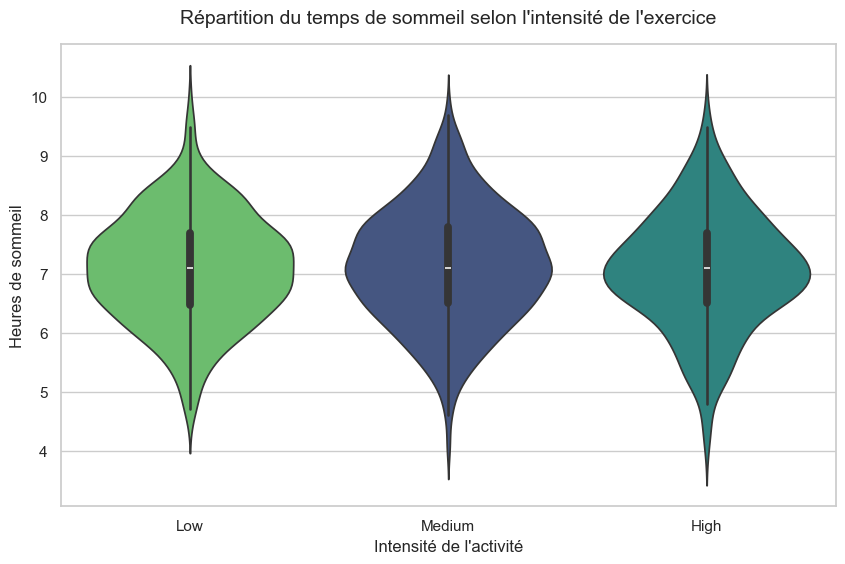

Moyenne de sommeil par niveau d'intensité :
intensity
High      7.057309
Low       7.087719
Medium    7.126957
Name: sleep_hours, dtype: float64


In [26]:
plt.figure(figsize=(10, 6))

# Création d'un graphique à moustaches combiné à la densité (Violin Plot)
sns.violinplot(data=df_act_sportifs, x='intensity', y='sleep_hours', 
               order=['Low', 'Medium', 'High'], palette='viridis', hue='intensity', legend=False)

plt.title("Répartition du temps de sommeil selon l'intensité de l'exercice", fontsize=14, pad=15)
plt.xlabel("Intensité de l'activité")
plt.ylabel("Heures de sommeil")

plt.show()

# Calcul des moyennes par groupe
print("Moyenne de sommeil par niveau d'intensité :")
print(df_act_sportifs.groupby('intensity')['sleep_hours'].mean().sort_values())

**Interprétation statistique :**

1. **Stabilité des moyennes :** Les moyennes de sommeil pour les intensités Faible (7.087h), Modérée (7.13h) et Élevée (7.057h) sont extrêmement proches. L'écart maximal entre le niveau Modéré et Élevé est de seulement 0.07h (environ 4 minutes), ce qui est physiologiquement négligeable.
2. **Analyse de la forme (Violin Plot) :** La largeur des "violons" et la position des quartiles (lignes blanches à l'intérieur) sont similaires pour les trois groupes. Cela montre que la distribution du sommeil reste constante, quel que soit l'effort fourni.

**Conclusion :** Ni le volume (pas/minutes) ni la qualité (intensité) de l'activité physique ne semblent expliquer de manière significative les variations du temps de sommeil dans cet échantillon. Cela renforce l'idée que le facteur "Stress" est un levier bien plus puissant pour comprendre le repos que l'activité physique elle-même.

## 8. Analyse Bivariée : Biométrie (BMI) et Sommeil

Pour terminer notre exploration des facteurs individuels, nous étudions l'influence de l'Indice de Masse Corporelle (BMI) sur la durée du sommeil. Nous cherchons à savoir si la morphologie du sportif est liée à ses besoins de récupération.

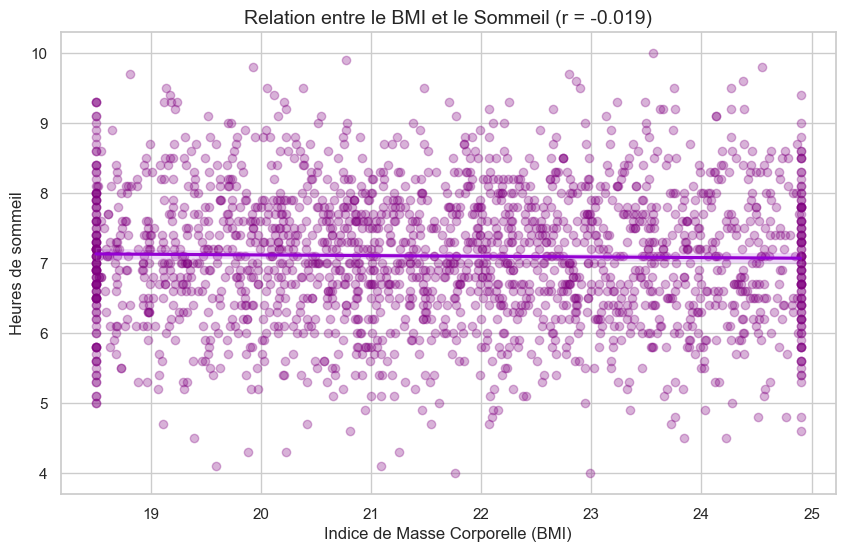

Coefficient de corrélation BMI / Sommeil : -0.019


In [27]:
plt.figure(figsize=(10, 6))

# Nuage de points avec droite de régression pour le BMI
sns.regplot(data=df_act_sportifs, x='bmi', y='sleep_hours', 
            scatter_kws={'alpha':0.3, 'color':'purple'}, 
            line_kws={'color':'darkviolet'})

# Calcul de la corrélation de Pearson
r_bmi, p_bmi = stats.pearsonr(df_act_sportifs['bmi'], df_act_sportifs['sleep_hours'])

plt.title(f"Relation entre le BMI et le Sommeil (r = {r_bmi:.3f})", fontsize=14)
plt.xlabel("Indice de Masse Corporelle (BMI)")
plt.ylabel("Heures de sommeil")

plt.show()

print(f"Coefficient de corrélation BMI / Sommeil : {r_bmi:.3f}")

**Interprétation statistique :**

1. **Absence de corrélation :** Le coefficient de Pearson est proche de zéro ($r = -0.019$). Cela confirme qu'il n'existe aucune relation linéaire entre l'Indice de Masse Corporelle (BMI) et le temps de sommeil chez ces sportifs.
2. **Observation graphique :** La droite de régression est parfaitement horizontale. Le nuage de points est uniformément réparti, ce qui signifie qu'un sportif avec un BMI faible (profil léger/endurance) ne dort statistiquement ni plus ni moins qu'un sportif avec un BMI plus élevé.

**Conclusion :** La morphologie (BMI) n'est pas un facteur important pour expliquer la durée de récupération dans ce jeu de données.

## 9. Analyse Bivariée : Type de sport et Sommeil

Nous avons vu que le volume et l'intensité de l'effort n'avaient que peu d'impact. Nous vérifions ici si la nature même de l'activité (Running, Swimming, Yoga, etc.) influence la durée de récupération. Cette variable est importante car elle fait partie des informations demandées dans notre futur formulaire web.

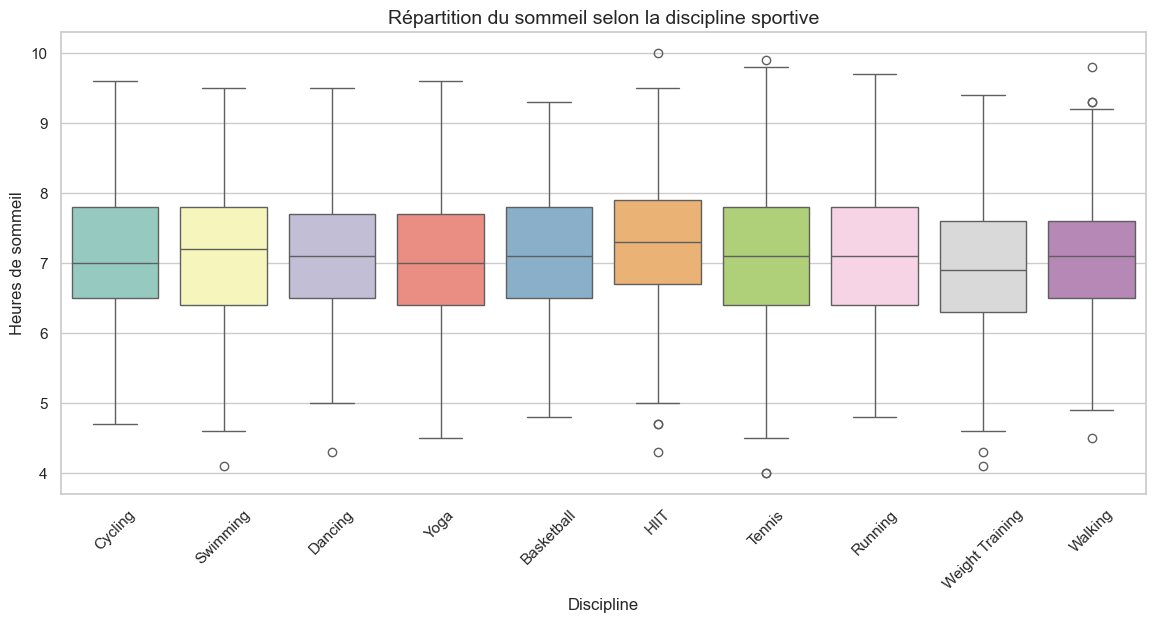

Sommeil moyen par discipline :
activity_type
HIIT               7.246465
Tennis             7.132127
Basketball         7.119672
Cycling            7.116583
Swimming           7.106466
Dancing            7.100518
Running            7.086364
Walking            7.083598
Yoga               7.083333
Weight Training    6.957767
Name: sleep_hours, dtype: float64


In [31]:
plt.figure(figsize=(14, 6))

# Comparaison du sommeil selon la discipline
sns.boxplot(data=df_act_sportifs, x='activity_type', y='sleep_hours', hue='activity_type', palette='Set3', legend=False)

plt.title("Répartition du sommeil selon la discipline sportive", fontsize=14)
plt.xticks(rotation=45)
plt.xlabel("Discipline")
plt.ylabel("Heures de sommeil")
plt.show()

# Affichage des moyennes exactes pour l'interprétation
print("Sommeil moyen par discipline :")
print(df_act_sportifs.groupby('activity_type')['sleep_hours'].mean().sort_values(ascending=False))

**Analyse des comportements par discipline :**

L'exploration des types d'activités montre des profils de dormeurs légèrement distincts selon le sport pratiqué :
* **Tendances hautes :** Les pratiquants de HIIT (7,25h) et de Tennis (7,13h) affichent les durées de sommeil les plus longues de l'échantillon.
* **Tendances basses :** La musculation (Weight Training) se distingue avec la moyenne la plus faible (6,96h).
* **Stabilité centrale :** La majorité des autres disciplines (Running, Swimming, Yoga) gravitent autour d'un pivot commun de 7,10h.

On observe donc que la nature de l'activité physique est un facteur de segmentation, même si les écarts de moyennes restent contenus dans une fourchette de 20 minutes environ.

## 10. Analyse des Facteurs de Santé et Mode de Vie

Pour finaliser l'exploration individuelle des variables de notre futur formulaire web, nous étudions l'impact du genre (`gender`), du statut tabagique (`smoking_status`) et du niveau d'hydratation (`hydration_level`) sur le sommeil. Nous décidons d'analyser les 3 dans le même bloc ci dessous :

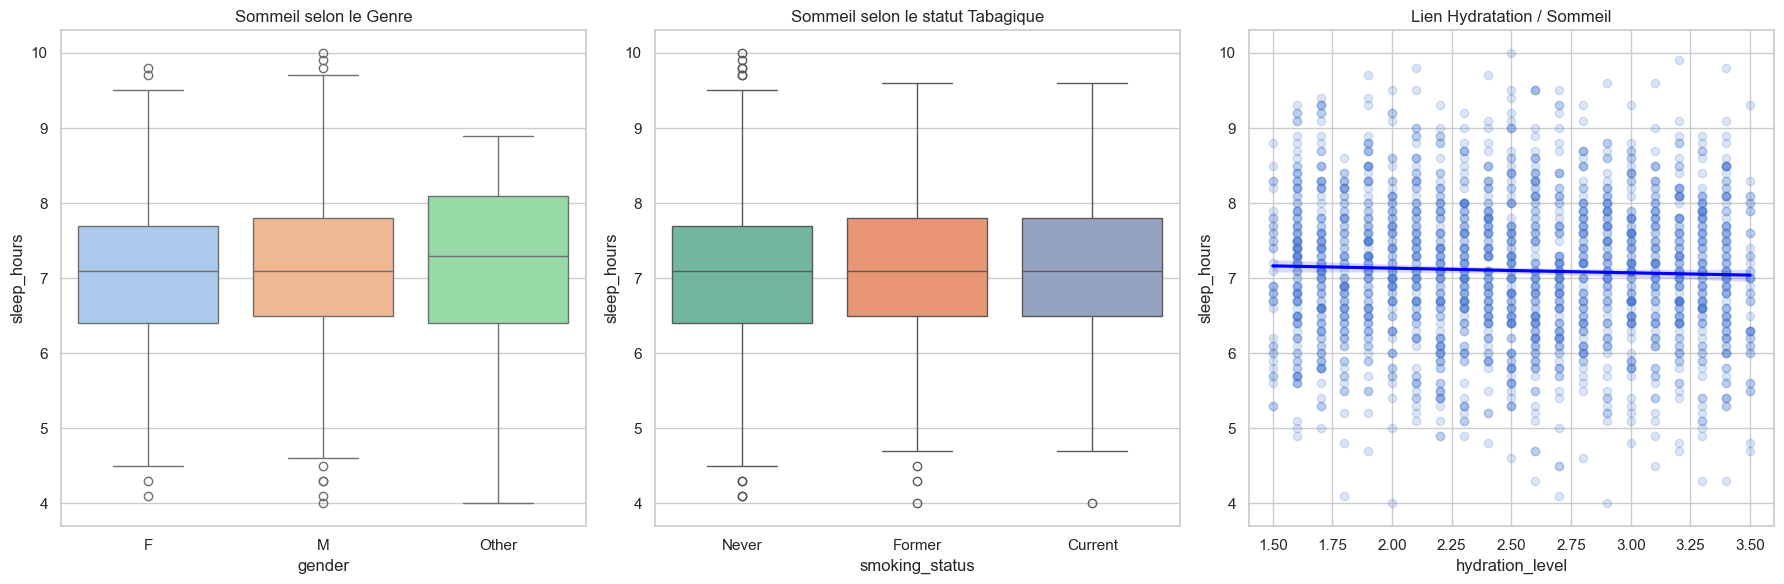

Corrélation Hydratation/Sommeil : -0.037


In [33]:
fig, ax = plt.subplots(1, 3, figsize=(18, 6))

# 1. Influence du Genre
sns.boxplot(ax=ax[0], data=df_act_sportifs, x='gender', y='sleep_hours', hue='gender', palette='pastel', legend=False)
ax[0].set_title("Sommeil selon le Genre")

# 2. Influence du Tabac
sns.boxplot(ax=ax[1], data=df_act_sportifs, x='smoking_status', y='sleep_hours', hue='smoking_status', palette='Set2', legend=False)
ax[1].set_title("Sommeil selon le statut Tabagique")

# 3. Influence de l'Hydratation
sns.regplot(ax=ax[2], data=df_act_sportifs, x='hydration_level', y='sleep_hours', scatter_kws={'alpha':0.2}, line_kws={'color':'blue'})
ax[2].set_title("Lien Hydratation / Sommeil")

plt.tight_layout()
plt.show()

print(f"Corrélation Hydratation/Sommeil : {df_act_sportifs['hydration_level'].corr(df_act_sportifs['sleep_hours']):.3f}")

**Observations sur les variables de mode de vie :**

L'analyse visuelle des facteurs de santé révèle une grande homogénéité dans l'échantillon :
* **Distribution par Genre et Tabagisme :** Les boîtes à moustaches sont quasiment superposables. Que ce soit pour le sexe ou le statut tabagique, les médianes et les dispersions (IQ) ne montrent pas de rupture franche.
* **Hydratation :** Avec un coefficient de $r = -0.037$, il n'existe aucune relation linéaire visible entre la consommation d'eau et la durée du sommeil.

À ce stade de l'exploration, ces variables de vie quotidienne semblent être des "bruits de fond" qui n'influencent pas directement la durée brute du repos de manière isolée.

## 11. Synthèse Globale et Justification du Formulaire Web

Pour conclure notre analyse exploratoire, nous regroupons l'intégralité des variables au sein d'une matrice de corrélation. Cette vue d'ensemble permet de valider la structure de notre futur outil de prédiction et de justifier l'exclusion de certaines variables techniques.

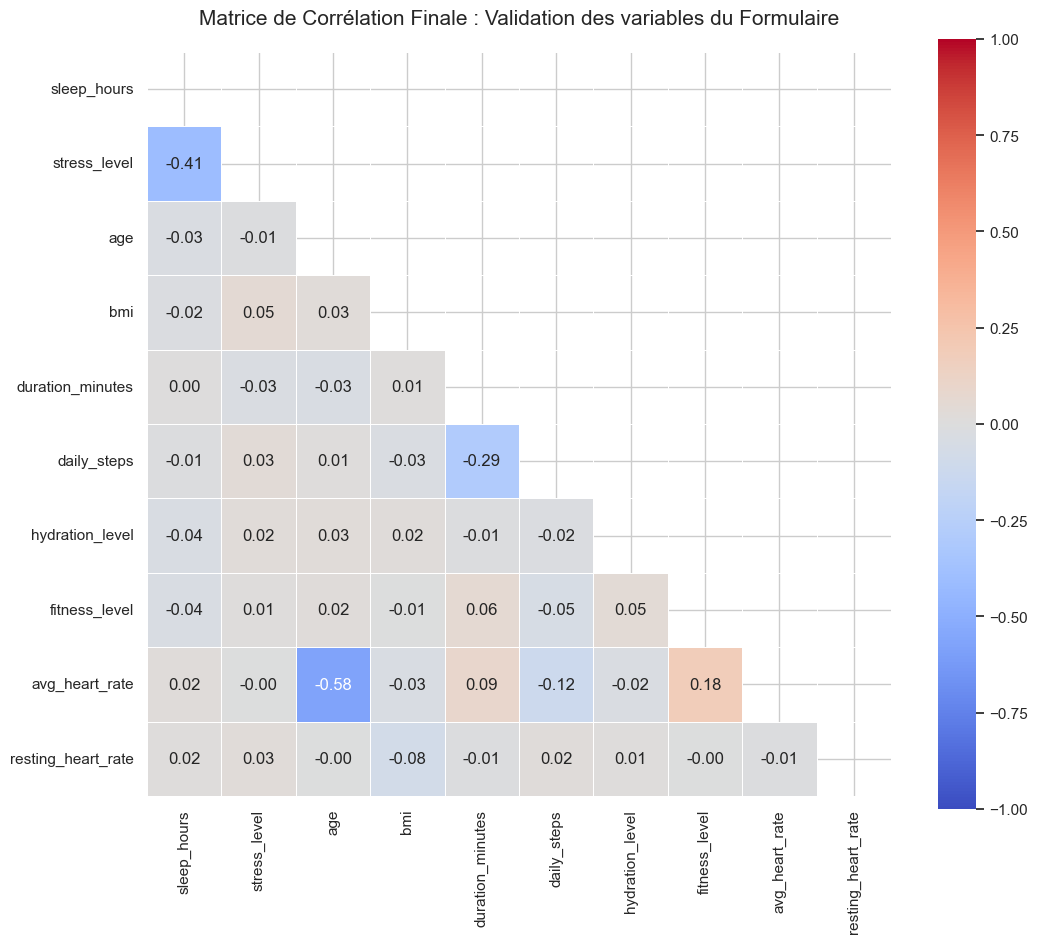

In [43]:
# Sélection des variables : celles du questionnaire + celles qu'on exclut 
colonnes_finales = [
    'sleep_hours', 'stress_level', 'age', 'bmi', 'duration_minutes', 
    'daily_steps', 'hydration_level', 'fitness_level', 'avg_heart_rate', 'resting_heart_rate'
]

# Calcul de la matrice
plt.figure(figsize=(12, 10))
corr_matrix = df_act_sportifs[colonnes_finales].corr()

sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap='coolwarm', 
            vmin=-1, vmax=1, center=0, square=True, linewidths=.5)

plt.title("Matrice de Corrélation Finale : Validation des variables du Formulaire", fontsize=15, pad=20)
plt.show()

**Interprétation de la Matrice de Corrélation (Base Activité) :**

* **Le stress prédomine :** C'est la variable la plus corrélée négativement avec le temps de sommeil. Plus le stress augmente, plus la durée de la nuit diminue.
* **Absence de liens physiques évidents :** Les variables comme le nombre de pas, la durée de l'exercice ou le BMI ne montrent pas de corrélation linéaire directe avec la durée de sommeil comme nous avons pu observer précédemment. 


## 12. Analyse Exploratoire : Base Sommeil (1196 profils)

Pour compléter notre étude, nous appliquons la même démarche analytique à notre seconde base de données sommeil_uniquement_sportifs.csv . L'objectif est d'analyser la quantité globale de sommeil dans cet échantillon et de vérifier si les tendances observées précédemment (notamment l'impact du stress) se confirment ici.

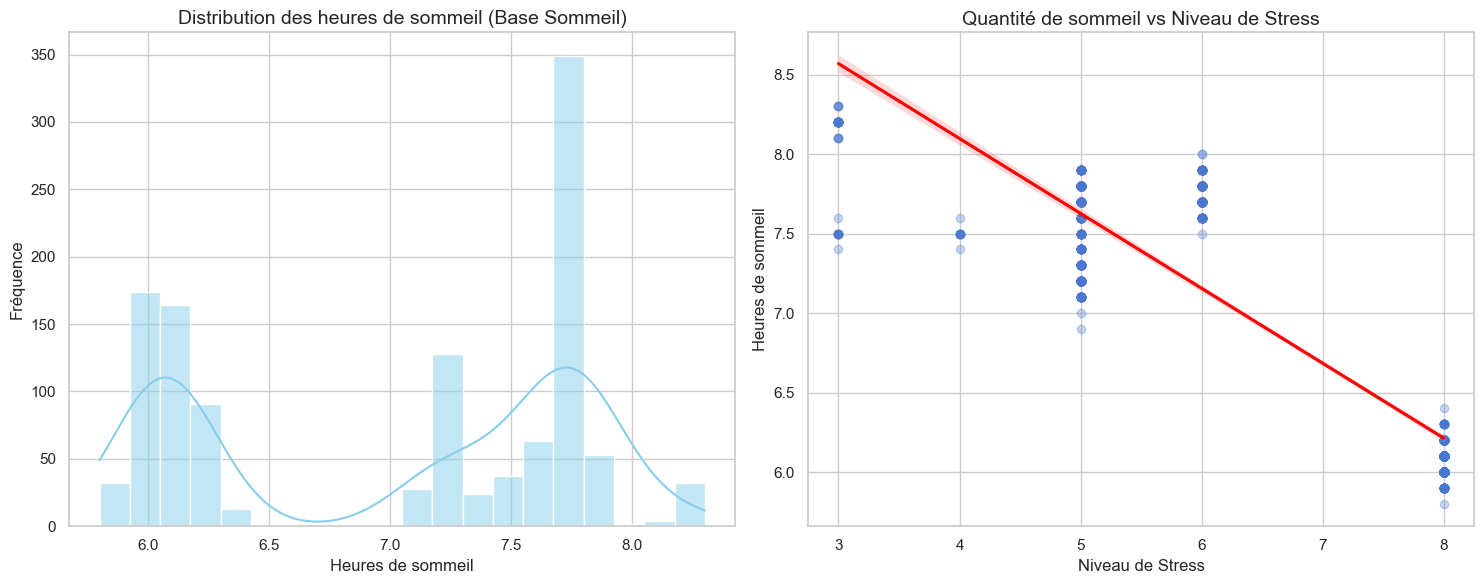

Statistiques de la quantité de sommeil (Base Sommeil) :
count    1196.000000
mean        7.013796
std         0.792001
min         5.800000
25%         6.100000
50%         7.300000
75%         7.700000
max         8.300000
Name: sleep_hours, dtype: float64


In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(15, 6))

# 1. Distribution de la durée du sommeil
sns.histplot(data=df_som_sportifs, x='sleep_hours', bins=20, kde=True, color='skyblue', ax=ax[0])
ax[0].set_title("Distribution des heures de sommeil (Base Sommeil)", fontsize=14)
ax[0].set_xlabel("Heures de sommeil")
ax[0].set_ylabel("Fréquence")

# 2. Relation avec le Stress (variable importante vu plus haut)
sns.regplot(data=df_som_sportifs, x='stress_level', y='sleep_hours', 
            scatter_kws={'alpha':0.3}, line_kws={'color':'red'}, ax=ax[1])
ax[1].set_title("Quantité de sommeil vs Niveau de Stress", fontsize=14)
ax[1].set_xlabel("Niveau de Stress")
ax[1].set_ylabel("Heures de sommeil")

plt.tight_layout()
plt.show()

print("Statistiques de la quantité de sommeil (Base Sommeil) :")
print(df_som_sportifs['sleep_hours'].describe())

**Analyse visuelle et premiers doutes sur la donnée :**

1. **Une distribution anormale (Graphique de gauche) :** Contrairement à la base `Activité` où le temps de sommeil formait une belle courbe en cloche naturelle (distribution gaussienne), l'histogramme de cette base `Sommeil` présente des pics extrêmement resserrés et artificiels, notamment autour de 6h et 7.7h. Dans la réalité biologique, les durées de sommeil humaines ne se regroupent pas de manière aussi robotique et segmentée.

2. **Une corrélation trop parfaite (Graphique de droite) :**
Le nuage de points croisant le Sommeil et le Stress vient confirmer nos premiers soupçons. Les points sont empilés en colonnes verticales parfaites sur des niveaux de stress très précis (3, 4, 5, 6, 8). De plus, la baisse du sommeil en fonction du stress suit une ligne droite presque sans aucune dispersion (très peu de "bruit" statistique). 

**Conclusion de cette étape :**
Plus nous avançons dans l'exploration de cette base `Sommeil`, plus les résultats paraissent louches. La perfection de ces alignements et l'absence de variations organiques (typiques des comportements humains) renforcent l'hypothèse que cette table n'a pas été récoltée sur de vrais sportifs, mais a été générée de toutes pièces par une formule mathématique. Nous allons poursuivre notre étude pour vérifier cela.

## 13. Matrice de corrélation : Quantité et Cycles (Base Sommeil)

Pour confirmer nos doutes sur la nature de cette base de données, nous allons générer une matrice de corrélation. Nous croisons ici la durée totale du sommeil (`sleep_hours`), le niveau de stress (`stress_level`), ainsi que les différentes phases internes de la nuit (sommeil profond, léger, paradoxal) et l'efficacité globale. L'objectif est de vérifier si les relations entre ces variables biologiques semblent naturelles ou mathématiquement programmées.

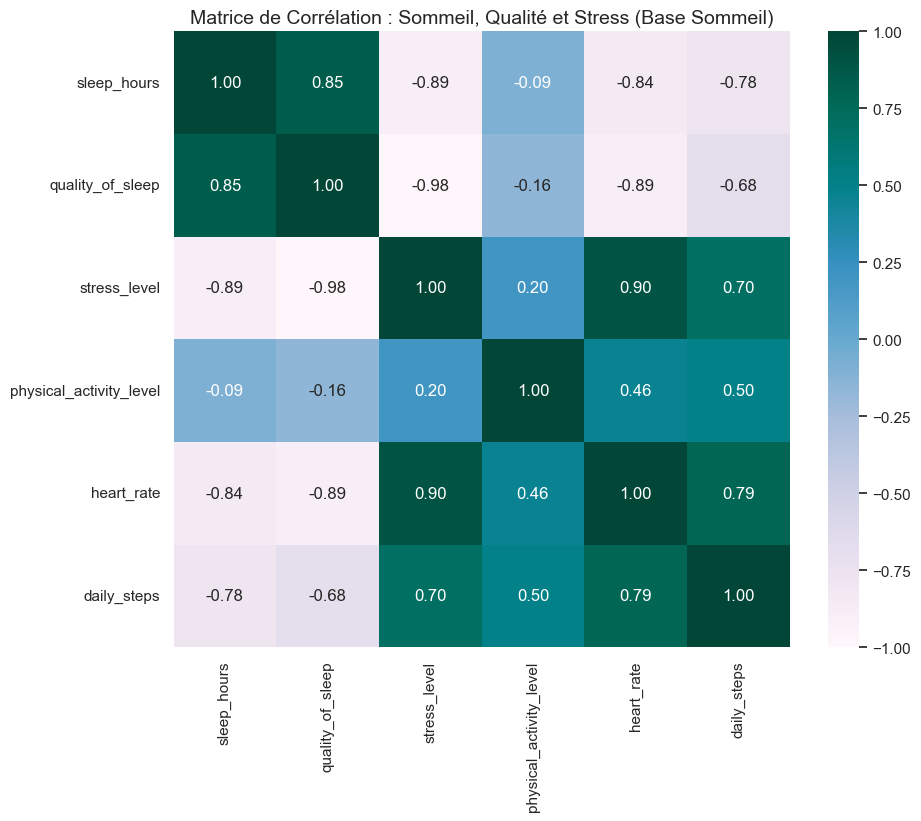

In [55]:
plt.figure(figsize=(10, 8))

cols_som = ['sleep_hours', 'quality_of_sleep', 'stress_level', 'physical_activity_level', 'heart_rate', 'daily_steps']
corr_som = df_som_sportifs[cols_som].corr()

sns.heatmap(corr_som, annot=True, cmap='PuBuGn', fmt=".2f", square=True, vmin=-1, vmax=1)
plt.title("Matrice de Corrélation : Sommeil, Qualité et Stress (Base Sommeil)", fontsize=14)
plt.show()

**Interprétation de la Matrice et Doutes sur la Donnée :**

L'analyse de cette matrice de corrélation vient confirmer nos soupçons. Les relations statistiques affichées ici sont quasiment parfaites :

1. **Des scores étonnamment élevés :** La corrélation entre le niveau de stress (`stress_level`) et la qualité du sommeil (`quality_of_sleep`) atteint le score de **-0.98**. Cela indique une relation linéaire négative presque totale. De même, la fréquence cardiaque (`heart_rate`) est corrélée à **0.90** avec le stress et à **-0.89** avec la qualité du sommeil.
2. **L'absence de bruit :** Dans des données biologiques réelles, les comportements humains génèrent habituellement une dispersion naturelle (du bruit statistique). Obtenir de multiples scores aussi extrêmes (autour de 0.90 et -0.90) suggère que ces variables pourraient être liées par une équation ou générées artificiellement.

**Ouverture vers le Machine Learning :**
Bien que ces résultats paraissent trop parfaits, notre future étude en Machine Learning nous permettra de vérifier cette hypothèse de manière concrète. En appliquant différents modèles prédictifs et en analysant leurs comportements face à cette absence de bruit, nous pourrons tester la robustesse de ces données et confirmer définitivement si cette base est synthétique.

## Conclusion Générale de l'Analyse Exploratoire (EDA)

Ce travail d'exploration approfondi nous a permis de comprendre la structure et les limites de nos jeux de données avant d'entamer toute modélisation. Voici le bilan structuré de nos découvertes.

### 1. Définition du Périmètre et Filtrage

L'étape initiale de nettoyage a été cruciale. Sur une base de départ de 3000 individus, nous avons isolé notre population cible : les sportifs. Cela nous a permis de constituer notre base principale de travail, la table Activité (2011 profils, soit 67% de l'échantillon initial), tout en observant une base secondaire nommée sommeil_uniquement_sportifs.csv (1196 profils de sportifs) pour des analyses complémentaires.

### 2. Enseignements de la Base Principale (Activité)

L'analyse des 2011 profils actifs a mis en évidence des dynamiques claires :

- **Le poids du facteur psychologique :**  
Le niveau de stress s'est imposé comme l'unique variable présentant une corrélation linéaire notable avec la baisse de la durée du sommeil.

- **La neutralité des facteurs physiques :**  
Contre toute attente, le volume d'entraînement (nombre de pas, durée) et la biométrie (BMI, âge) n'expliquent pas le sommeil de manière isolée. Un sportif qui s'entraîne plus longtemps ne dort pas automatiquement plus.

### 3. L'Anomalie de la Base Secondaire (Sommeil)

L'exploration de notre seconde base, censée nous éclairer sur la qualité et l'architecture des nuits, a révélé autre chose:

- **Des résultats trop parfaits :**  
L'analyse des corrélations a montré des scores extrêmes, notamment une corrélation de -0.98 entre le stress et la qualité du sommeil, ou encore de 0.90 avec la fréquence cardiaque.

- **Un doute légitime :**  
L'absence totale de "bruit" statistique soulève l'hypothèse très forte que ce jeu de données spécifique a été généré de manière synthétique, s'éloignant d'une réalité biologique organique.

### 4. Perspectives : Transition vers le Machine Learning

Les limites de l'analyse statistique classique (bivariée) sont désormais atteintes. La suite logique est donc l'utilisation du Machine Learning, avec un double objectif stratégique :

- **Un objectif de Modélisation (Base Activité) :**  
Puisqu'aucune variable physique ne permet à elle seule de prédire le besoin de sommeil, nous entraînerons un algorithme capable de croiser simultanément nos multiples variables (stress, âge, sport, hydratation). Le but sera de détecter des interactions complexes et multidimensionnelles pour estimer le besoin de récupération d'un utilisateur.

- **Un objectif de Vérification (Base Sommeil) :**  
Nous utiliserons nos modèles prédictifs pour tester la robustesse des données de la base Sommeil. En observant le comportement des algorithmes face à cette absence de bruit statistique, nous pourrons valider notre hypothèse et confirmer définitivement si cette base est artificielle.